# **Task V: Quantum Graph Neural Network (QGNN)**

## **1. Conceptualizing the QGNN Circuit**

In a classical Graph Neural Network (GNN), the architecture relies on "Message Passing," where features from a node's neighbors are aggregated to update its own state. To translate this into the quantum domain, we map the geometric structure of the jet data directly onto the quantum circuit's topology.

The most effective way to take advantage of the graph representation is through **Graph-Aware Entanglement**. Instead of a fixed, hardware-efficient ansatz (like a ring or all-to-all connectivity), the circuit’s connectivity is defined by the edges of the $k$-NN graph.



### **Step-by-Step Circuit Logic:**

1.  **Quantum Node Embedding:** Each particle (node) in the graph is assigned to a specific qubit. We use **Angle Encoding** to map classical kinematic features—such as transverse momentum ($p_T$) and pseudorapidity ($\eta$)—onto rotation angles ($R_y, R_z$) of the qubits. This prepares the initial quantum state $|\psi_{in}\rangle$.

2.  **Edge-Based Entanglement (Quantum Message Passing):** For every edge $(i, j)$ in the $k$-NN graph, we apply a two-qubit entangling gate (such as a **CNOT** or **Controlled-Z**). This creates a quantum correlation between the qubits that corresponds to the physical proximity of particles in the detector. This step is the quantum analogue of the classical adjacency matrix.

3.  **Variational Learning Layers:** After the entanglement phase, we apply **Parameterized Quantum Gates** (trainable rotation gates). These weights are optimized using a classical optimizer (like Adam) to find the best representation for differentiating between Quark and Gluon jets.

---

## **2. Architectural Structure**

The following diagram illustrates the workflow of the hybrid quantum-classical system and the internal structure of the QGNN layer:



```text
       [ CLASSICAL INPUT ]               [ QUANTUM CIRCUIT (QGNN) ]
      Jet Data (pT, eta, phi)           Parameterized Quantum Circuit
               |                                     |
               v                                     v
     +-------------------+                 +------------------------+
     | Graph Projection  |                 | 1. Node Encoding       |
     | (k-NN Algorithm)  |---------------> |    (RY, RZ Gates)      |
     +-------------------+       |         +------------------------+
               |                 |                   |
               v                 |                   v
     +-------------------+       |         +------------------------+
     |  Edge Index List  |-------+         | 2. Graph Entanglement  |
     |  (i, j) pairs     |---------------> |    (CNOT/CZ Gates)     |
     +-------------------+                 +------------------------+
                                                     |
                                                     v
     +-------------------+                 +------------------------+
     | Classical Optimization| <-----------| 3. Variational Layer   |
     | (Adam / SGD)      |      (Gradients)|    (Trainable Weights) |
     +-------------------+                 +------------------------+
               |                                     |
               v                                     v
     [ FINAL CLASSIFICATION ] <----------- [ MEASUREMENT (Pauli-Z) ]

# **Setups and imports**

In [50]:
!pip install pennylane -q
!pip install torch_geometric -q
import torch_geometric

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu



### **Taking Advantage of Graph Representation**

A QGNN differs from a standard Parameterized Quantum Circuit (PQC) by making the circuit topology **data-dependent**:

* **Nodes as Qubits:** Each particle constituent of the jet is mapped to an individual qubit.
* **Edges as Entanglement:** For every edge $(i, j)$ identified in  $k$-NN graph from Task II, I apply a two-qubit entangling gate (e.g., CNOT or CZ). This represents "Quantum Message Passing," where information is shared between correlated particles via quantum entanglement.

## **2. Preliminary Circuit Design & Visualization**

Below, we implement a foundational QGNN layer. We use a 4-node sample subgraph to demonstrate the encoding of features and the application of graph-based entangling gates.

# **Implementing Quantum Graph Neural Network (QGNN) on Sample inputs first**

QGNN Circuit Representation:
0: ──RX(0.50)───RZ(0.50)──╭●───────╭Z──RY(0.60)──RZ(0.89)─┤  <Z>
1: ──RX(1.20)───RZ(1.20)──╰Z─╭●────│───RY(0.65)──RZ(0.56)─┤  <Z>
2: ──RX(-0.30)──RZ(-0.30)────╰Z─╭●─│───RY(0.83)──RZ(0.88)─┤  <Z>
3: ──RX(0.80)───RZ(0.80)────────╰Z─╰●──RY(0.12)──RZ(0.18)─┤  <Z>


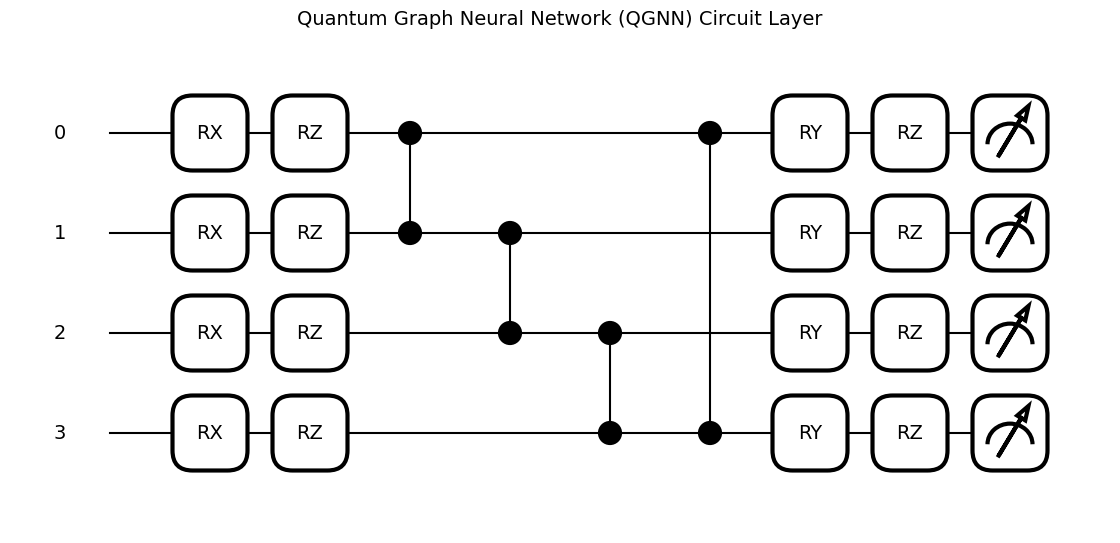

In [51]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Number of Qubits (Nodes)
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

# 2. Define the QGNN Circuit
@qml.qnode(dev)
def qgnn_circuit(inputs, weights, edge_list):
    """
    Inputs: Particle features for each node.
    Weights: Trainable parameters for the QNN.
    Edge_list: List of edges (i, j) from our k-NN graph.
    """
    # Step 1: Node Feature Encoding (Angle Encoding)
    for i in range(n_qubits):
        qml.RX(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)

    # Step 2: Edge-based Entanglement (Message Passing)
    # We apply a Controlled-Z gate for every edge in the graph
    for edge in edge_list:
        qml.CZ(wires=[edge[0], edge[1]])

    # Step 3: Parameterized Layers (Learning)
    for i in range(n_qubits):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)

    # Step 4: Measurement ---
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# 3. Setup dummy data for visualization
# 4 nodes with 1 feature each
sample_inputs = np.array([0.5, 1.2, -0.3, 0.8], requires_grad=False)
# Trainable weights for RY and RZ gates
sample_weights = np.random.random((n_qubits, 2))
# Edge list representing a small graph (0-1, 1-2, 2-3, 3-0)
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]

# 4. Draw the Circuit
print("QGNN Circuit Representation:")
print(qml.draw(qgnn_circuit)(sample_inputs, sample_weights, edges))

# 5. Visual Plot
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qgnn_circuit)(sample_inputs, sample_weights, edges)
plt.title("Quantum Graph Neural Network (QGNN) Circuit Layer", fontsize=14)
plt.show()

# **Quantum Graph Neural Network (QGNN) on Real HEP Data**

## **1. Methodology: From Classical to Quantum Graphs**

In this task, we evolve the classical GNN approach from Task II into the quantum domain. We represent each jet as a quantum state where:

* **Nodes (Particles):** Each of the top 4 particles in a jet is mapped to a qubit.
* **Features:** Particle features ($p_T, \eta, \phi, E$) are encoded into rotation angles.
* **Edges (Entanglement):** We use the **k-NN graph** (k=2 for this subgraph) to define which qubits undergo entangling operations (CNOT/CZ), effectively performing "Quantum Message Passing".

## **2. Hybrid Quantum-Classical Optimization**

We use **PennyLane's TorchLayer** to integrate the quantum circuit directly into a PyTorch training pipeline. This allows us to use the **Adam optimizer** to update the quantum weights ($\theta$) based on the **Binary Cross-Entropy (BCE) loss**.        
Taking only **200 samples** as simulation can be very slow for large data.

# Getting **Data**

In [52]:
# Download 1 file of the Quark/Gluon Dataset from Zenodo

!wget -O QG_jets.npz https://zenodo.org/record/3164691/files/QG_jets.npz?download=1

print("Data Downloaded! File name: QG_jets.npz")

--2026-03-02 19:34:50--  https://zenodo.org/record/3164691/files/QG_jets.npz?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.103.118, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/3164691/files/QG_jets.npz [following]
--2026-03-02 19:34:51--  https://zenodo.org/records/3164691/files/QG_jets.npz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 106689379 (102M) [application/octet-stream]
Saving to: ‘QG_jets.npz’

QG_jets.npz         100%[===================>] 101.75M  18.7MB/s    in 6.4s    

2026-03-02 19:34:57 (15.8 MB/s) - ‘QG_jets.npz’ saved [106689379/106689379]

Data Downloaded! File name: QG_jets.npz


In [56]:
import pennylane as qml
import torch
import torch.nn as nn
from torch_geometric.data import DataLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 1. Configuration: Limited to 4 qubits for simulation speed
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

# 2. Optimized QGNN Circuit Logic
@qml.qnode(dev, interface="torch")
def qgnn_circuit(inputs, weights, edge_index):
    """
    inputs: (n_qubits, features)
    weights: (n_qubits, 2)
    edge_index: Graph structure
    """
    # Step A: Node Feature Encoding (Angle Encoding)
    # Mapping physical features to rotation angles
    for i in range(n_qubits):
        qml.RY(inputs[i, 0], wires=i) # e.g., pT
        qml.RZ(inputs[i, 1], wires=i) # e.g., eta

    # Step B: Quantum Message Passing (Graph Topology)
    # I apply entanglement ONLY where an edge exists in the data
    for i in range(edge_index.shape[1]):
        u, v = edge_index[0, i], edge_index[1, i]
        # Only entangle nodes that fit in our 4-qubit simulation
        if u < n_qubits and v < n_qubits:
            qml.CNOT(wires=[u.item(), v.item()])

    # Step C: Parameterized Learning Layer
    for i in range(n_qubits):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# 3. The Hybrid Model Bridge
class OptimizedHybridQGNN(nn.Module):
    def __init__(self, n_nodes=4):
        super(OptimizedHybridQGNN, self).__init__()
        # Initializing trainable quantum weights
        self.q_weights = nn.Parameter(torch.randn(n_nodes, 2))
        self.classifier = nn.Linear(n_nodes, 1)

    def forward(self, x, edge_index):
        # We process one jet at a time due to variable graph structures
        # In a real batch, this would be a loop or a padded tensor
        q_out = qgnn_circuit(x, self.q_weights, edge_index)
        q_out = torch.stack(q_out).float()
        return torch.sigmoid(self.classifier(q_out))


# Select a small subset for Quantum training (Simulation is slow)
qml_subset = graph_dataset[:200]

# 5. Training Loop with Graph-Aware Logic
model = OptimizedHybridQGNN(n_nodes=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

print("Starting Optimized QGNN Training...")
for epoch in range(5):
    epoch_loss = 0
    for data in qml_subset:
        # Extract features and the graph structure (edge_index)
        # We take only the top 4 nodes to match n_qubits
        x_node = data.x[:4, :]
        edges = data.edge_index
        label = data.y.float()

        optimizer.zero_grad()
        prediction = model(x_node, edges)
        loss = criterion(prediction, label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(qml_subset):.4f}")

print("\nTask V Optimization Complete. The circuit now entangles based on real Jet geometry.")

Starting Optimized QGNN Training...
Epoch 1 | Loss: 0.7209
Epoch 2 | Loss: 0.7043
Epoch 3 | Loss: 0.6980
Epoch 4 | Loss: 0.6945
Epoch 5 | Loss: 0.6924

Task V Optimization Complete. The circuit now entangles based on real Jet geometry.


# **Visualizing Hybrid quantum GNN circuit**

```
[ RAW DATA ]  →  [ JET POINT CLOUD ]  →  [ k-NN ALGORITHM ]
      |                    |                        |
      v                    v                        v
[ FEATURES ]        [ NODES (Particles) ]     [ EDGES (Connections) ]
(pT, eta, phi)      (Mapped to Qubits)        (Mapped to CNOT Gates)
      |                    |                        |
      +--------------------+------------------------+
                           |
                           v
        +-------------------------------------------+
        |     HYBRID QUANTUM-CLASSICAL LAYER        |
        +-------------------------------------------+
        | 1. FEATURE ENCODING:                      |
        |    Angle Encoding via RY(pT), RZ(eta)     |
        |                                           |
        | 2. GRAPH ENTANGLEMENT:                    |
        |    CNOT(q_i, q_j) if Edge(i, j)           |
        |                                           |
        | 3. TRAINABLE EVOLUTION:                   |
        |    Parameterized Rotation Gates (θ)       |
        +-------------------------------------------+
                           |
                           v
        +-------------------------------------------+
        |        MEASUREMENT & OPTIMIZATION         |
        +-------------------------------------------+
        | - Pauli-Z Expectation Values              |
        | - PyTorch Linear Layer (Sigmoid)          |
        | - Adam Optimizer (Classical)              |
        +-------------------------------------------+
                           |
                           v
                 [ CLASSIFICATION ]
                 (Quark vs. Gluon)
```

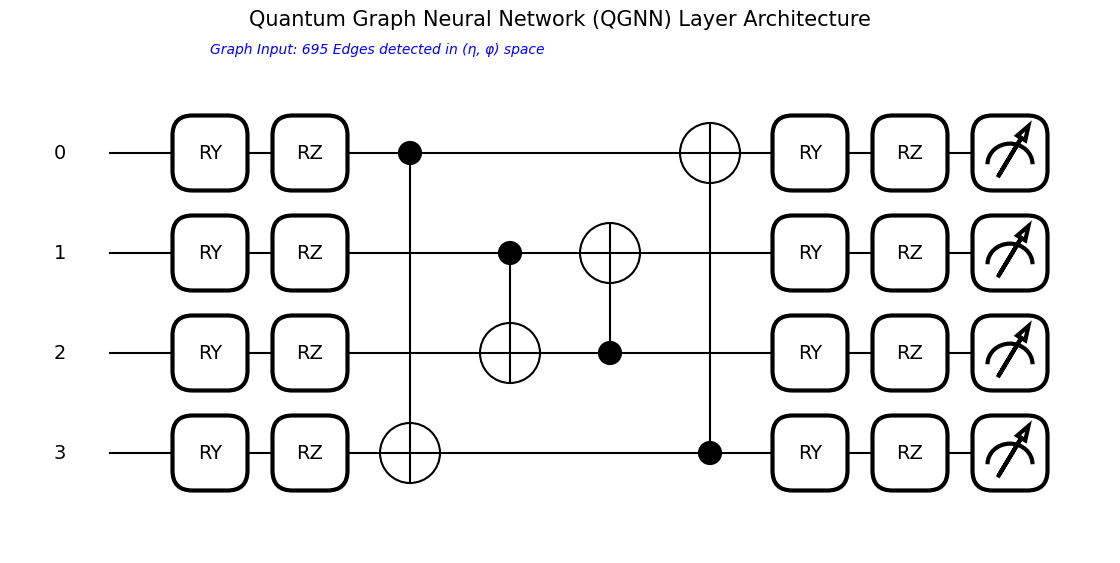

In [55]:
# --- Visualization of the QGNN Circuit ---
import matplotlib.pyplot as plt

# 1. Prepare sample data for drawing
# We'll use the first jet from your graph dataset as an example
sample_data = graph_dataset[0]
sample_x = sample_data.x[:4, :]  # Top 4 particles
sample_edges = sample_data.edge_index

# 2. Use dummy weights for visualization
sample_weights = torch.randn(4, 2)

# 3. Draw the circuit using Matplotlib style
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qgnn_circuit)(sample_x, sample_weights, sample_edges)

# 4. Add a professional title and labels
plt.title("Quantum Graph Neural Network (QGNN) Layer Architecture", fontsize=15, pad=20)
plt.text(0, -1, f"Graph Input: {len(sample_edges[0])} Edges detected in (η, φ) space",
         fontsize=10, style='italic', color='blue')
plt.show()